# Projet Speed Dating

## Objectif

Dans ce notebook, j'analyse un jeu de données de speed dating pour comprendre ce qui peut favoriser un match.

## Import des librairies et chargement du dataset

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("Speed_Dating_Data.csv", encoding="latin1")
df.head()

,iid,id,gender,idg,condtn,wave,round,position,positin1,order,...,attr3_3,sinc3_3,intel3_3,fun3_3,amb3_3,attr5_3,sinc5_3,intel5_3,fun5_3,amb5_3
0,1,1.0,0,1,1,1,10,7,NaN,4,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
1,1,1.0,0,1,1,1,10,7,NaN,3,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
2,1,1.0,0,1,1,1,10,7,NaN,10,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
3,1,1.0,0,1,1,1,10,7,NaN,5,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN
4,1,1.0,0,1,1,1,10,7,NaN,7,...,5.0,7.0,7.0,7.0,7.0,NaN,NaN,NaN,NaN,NaN


## EDA

In [2]:
print("Taille du dataset :" , df.shape)

Taille du dataset : (8378, 195)


In [3]:
missing = (df.isna().mean() * 100).sort_values(ascending=False).head(15)
missing

num_in_3    92.026737
numdat_3    82.143710
expnum      78.515159
sinc7_2     76.665075
amb7_2      76.665075
shar7_2     76.438291
attr7_2     76.318931
intel7_2    76.318931
fun7_2      76.318931
amb5_3      75.936978
attr7_3     75.936978
sinc7_3     75.936978
intel7_3    75.936978
fun7_3      75.936978
amb7_3      75.936978
dtype: float64

Le dataset contient beaucoup de variables et plusieurs valeurs manquantes. Je vais donc me concentrer sur les colonnes les plus utiles pour comprendre les décisions et les matches.


## Comprendre la variable cible : `match`

In [4]:
match_rate = df["match"].mean() * 100
dec_rate = df["dec"].mean() * 100
dec_o_rate = df["dec_o"].mean() * 100

print(f"Taux de match : {match_rate:.2f}%")
print(f"Taux de oui de la personne observée : {dec_rate:.2f}%")
print(f"Taux de oui du partenaire : {dec_o_rate:.2f}%")

Taux de match : 16.47%
Taux de oui de la personne observée : 41.99%
Taux de oui du partenaire : 41.96%


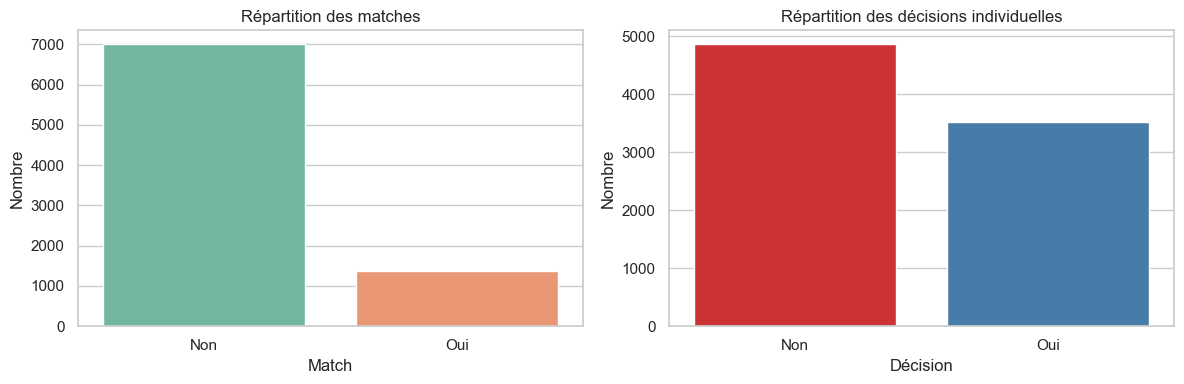

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.countplot(data=df, x="match", hue="match", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("Répartition des matches")
axes[0].set_xlabel("Match")
axes[0].set_ylabel("Nombre")
axes[0].set_xticks([0, 1], ["Non", "Oui"])

sns.countplot(data=df, x="dec", hue="dec", palette="Set1", legend=False, ax=axes[1])
axes[1].set_title("Répartition des décisions individuelles")
axes[1].set_xlabel("Décision")
axes[1].set_ylabel("Nombre")
axes[1].set_xticks([0, 1], ["Non", "Oui"])

plt.tight_layout()
plt.show()

### Interprétation

Le match reste rare, autour de 16 %. C'est logique, car il faut que les deux personnes disent oui.


## Ce que recherchent les participants

In [6]:
df["gender_label"] = df["gender"].map({0: "Femme", 1: "Homme"})

preference_cols = ["attr1_1", "sinc1_1", "intel1_1", "fun1_1", "amb1_1", "shar1_1"]
preferences = (
    df.groupby("gender_label")[preference_cols]
    .mean()
    .round(2)
    .T
    .rename(columns={"Femme": "Femmes", "Homme": "Hommes"})
)
preferences

/var/folders/5f/80v9jyrj6sj__198sx_v62f40000gn/T/ipykernel_5332/2932016698.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["gender_label"] = df["gender"].map({0: "Femme", 1: "Homme"})


gender_label,Femmes,Hommes
attr1_1,18.06,26.92
sinc1_1,18.31,16.50
intel1_1,21.00,19.54
fun1_1,17.15,17.76
amb1_1,12.83,8.55
shar1_1,12.70,11.00


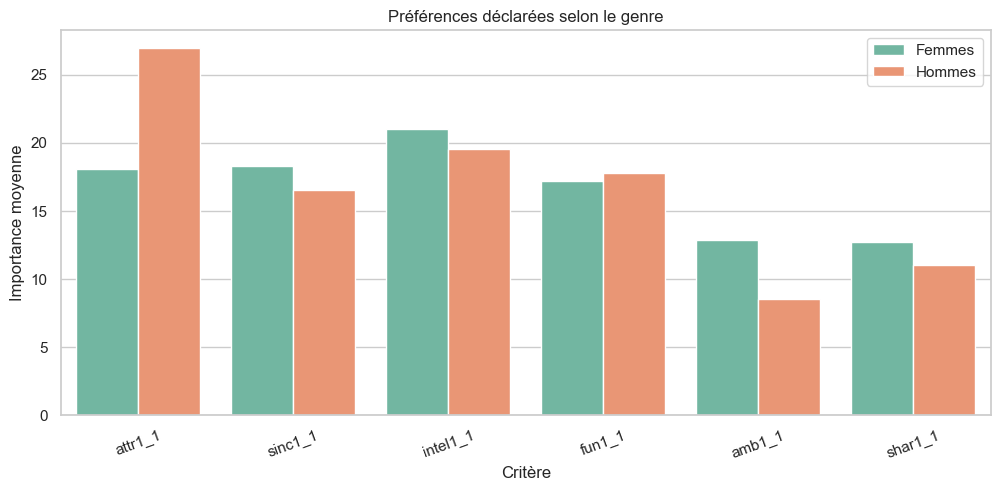

In [7]:
pref_plot = preferences.reset_index().rename(columns={"index": "critère"})
pref_plot = pref_plot.melt(id_vars="critère", var_name="groupe", value_name="importance")

plt.figure(figsize=(12, 5))
sns.barplot(data=pref_plot, x="critère", y="importance", hue="groupe", palette="Set2")
plt.title("Préférences déclarées selon le genre")
plt.xlabel("Critère")
plt.ylabel("Importance moyenne")
plt.xticks(rotation=20)
plt.legend(title="")
plt.show()

### Interprétation

Les hommes donnent plus d'importance à l'attractivité. Les femmes mettent un peu plus en avant l'intelligence, la sincérité et l'ambition. Les attentes ne sont donc pas exactement les mêmes.


## Ce qui pousse une personne à dire oui

In [8]:
rating_cols = ["attr", "sinc", "intel", "fun", "amb", "shar", "like", "prob"]

decision_means = df.groupby("dec")[rating_cols].mean().round(2)
decision_means.index = ["A dit non", "A dit oui"]
decision_means

,attr,sinc,intel,fun,amb,shar,like,prob
A dit non,5.37,6.86,7.08,5.70,6.49,4.72,5.31,4.63
A dit oui,7.29,7.60,7.76,7.33,7.16,6.46,7.22,5.97


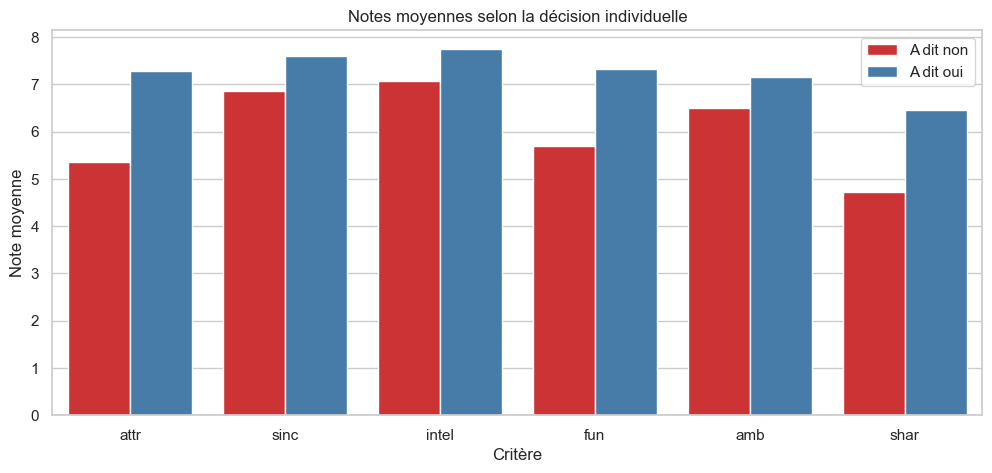

In [9]:
decision_plot = df.groupby("dec")[["attr", "sinc", "intel", "fun", "amb", "shar"]].mean().T.reset_index()
decision_plot.columns = ["critère", "A dit non", "A dit oui"]
decision_plot = decision_plot.melt(id_vars="critère", var_name="décision", value_name="score")

plt.figure(figsize=(12, 5))
sns.barplot(data=decision_plot, x="critère", y="score", hue="décision", palette="Set1")
plt.title("Notes moyennes selon la décision individuelle")
plt.xlabel("Critère")
plt.ylabel("Note moyenne")
plt.legend(title="")
plt.show()

In [10]:
corr_dec = df[rating_cols + ["dec"]].corr(numeric_only=True)["dec"].sort_values(ascending=False)
corr_dec

dec      1.000000
like     0.513463
attr     0.486775
fun      0.414477
shar     0.400644
prob     0.310861
intel    0.217313
sinc     0.209994
amb      0.183659
Name: dec, dtype: float64

### Interprétation

Quand une personne dit oui, les notes sont souvent plus élevées. L'attractivité compte beaucoup, mais le fun, l'intelligence, la sincérité et les intérêts communs jouent aussi un rôle.


## Ce qui favorise un match

In [11]:
match_means = df.groupby("match")[rating_cols].mean().round(2)
match_means.index = ["Pas de match", "Match"]
match_means

,attr,sinc,intel,fun,amb,shar,like,prob
Pas de match,5.96,7.05,7.25,6.16,6.66,5.21,5.88,4.96
Match,7.32,7.81,7.95,7.60,7.33,6.75,7.38,6.41


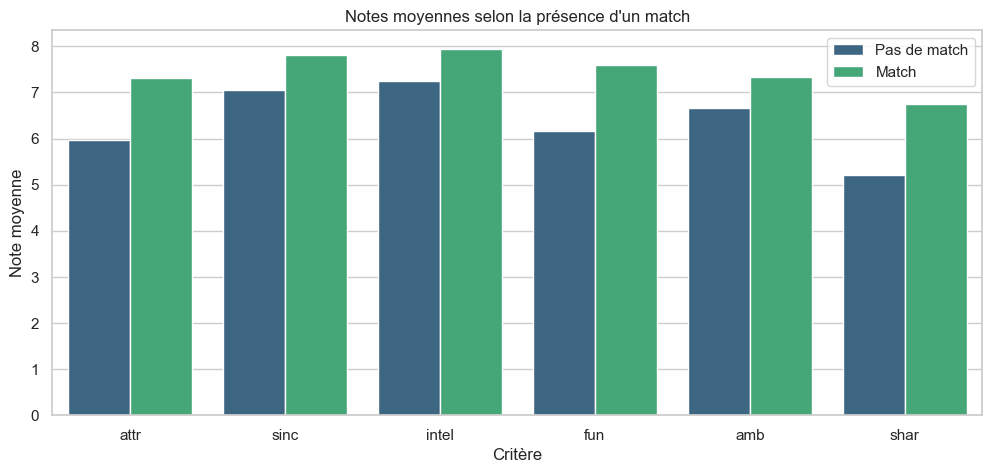

In [12]:
match_plot = df.groupby("match")[["attr", "sinc", "intel", "fun", "amb", "shar"]].mean().T.reset_index()
match_plot.columns = ["critère", "Pas de match", "Match"]
match_plot = match_plot.melt(id_vars="critère", var_name="statut", value_name="score")

plt.figure(figsize=(12, 5))
sns.barplot(data=match_plot, x="critère", y="score", hue="statut", palette="viridis")
plt.title("Notes moyennes selon la présence d'un match")
plt.xlabel("Critère")
plt.ylabel("Note moyenne")
plt.legend(title="")
plt.show()

In [13]:
corr_match = df[rating_cols + ["match"]].corr(numeric_only=True)["match"].sort_values(ascending=False)
corr_match

match    1.000000
like     0.305723
fun      0.277545
shar     0.270679
attr     0.260676
prob     0.255531
intel    0.169532
sinc     0.164449
amb      0.140042
Name: match, dtype: float64

Les matches arrivent surtout quand la rencontre est bien notée sur plusieurs points à la fois. Les variables les plus liées au match sont l'appréciation globale (`like`), l'attractivité (`attr`), le fun et les intérêts communs (`shar`).


## Autre analyse

In [23]:
analysis_df = df.copy()
analysis_df["age_gap"] = (analysis_df["age"] - analysis_df["age_o"]).abs()

print("Écart d'âge moyen selon le match :")
print(analysis_df.groupby("match")["age_gap"].mean().round(3))
print()
print("Taux de match selon samerace :")
print(analysis_df.groupby("samerace")["match"].mean().round(3))

Écart d'âge moyen selon le match :
match
0    3.752
1    3.182
Name: age_gap, dtype: float64

Taux de match selon samerace :
samerace
0    0.161
1    0.171
Name: match, dtype: float64


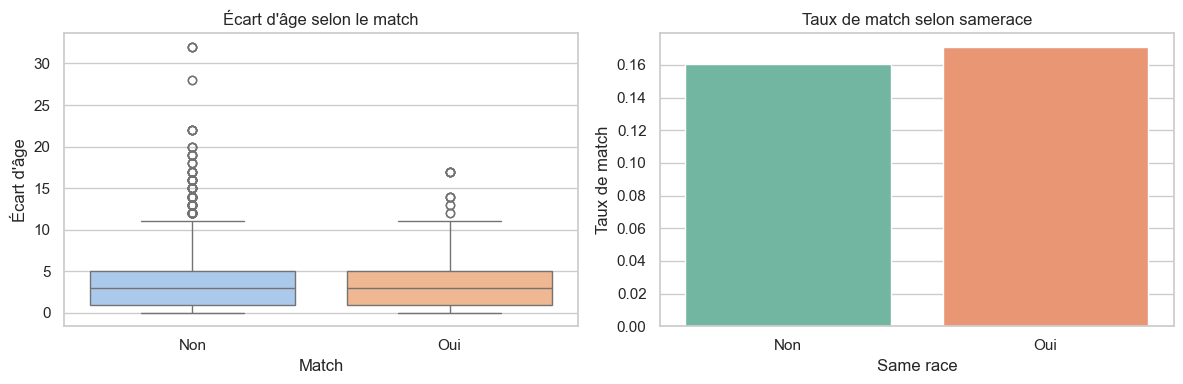

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=analysis_df, x="match", y="age_gap", hue="match", palette="pastel", legend=False, ax=axes[0])
axes[0].set_title("Écart d'âge selon le match")
axes[0].set_xlabel("Match")
axes[0].set_ylabel("Écart d'âge")
axes[0].set_xticks([0, 1], ["Non", "Oui"])

same_race = analysis_df.groupby("samerace", dropna=True)["match"].mean().reset_index()
sns.barplot(data=same_race, x="samerace", y="match", hue="samerace", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Taux de match selon samerace")
axes[1].set_xlabel("Same race")
axes[1].set_ylabel("Taux de match")
axes[1].set_xticks([0, 1], ["Non", "Oui"])

plt.tight_layout()
plt.show()

Un écart d'âge plus faible semble aider légèrement. Être de la même race augmente aussi un peu le taux de match, mais ces effets restent plus faibles que les notes données pendant l'interaction.


## Conclusion

Le taux de match est faible, car il faut deux réponses positives. Les préférences changent un peu selon le genre, mais la décision dépend surtout de l'impression générale : attractivité, fun, appréciation et intérêts communs.

Au final, un match ne dépend pas seulement du physique. L'alchimie générale du rendez-vous semble très importante.
